# Adult / Census Income Dataset — Analysis & Modeling

This notebook walks through:
1. Descriptive analysis (EDA)
2. Data preparation for ML
3. Model training (Logistic Regression, Decision Tree, Random Forest, XGBoost, SVM, Naive Bayes, AdaBoost, KNN — 8 models total)
4. Evaluation (accuracy, precision, recall, F1, ROC-AUC, confusion matrices, feature importance), validated on both internal validation split and the official held-out `adult.test` file

Expects `adult.data` and `adult.test` in the same folder as this notebook (original UCI train/test split). All plots are also saved to an `outputs/` folder. See Section 1.1 for exactly how each data file is used throughout.

**Task:** predict whether a person's annual income is `<=50K` or `>50K` based on census/demographic attributes.

## 0. Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, RocCurveDisplay)
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier


sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42

os.makedirs('outputs', exist_ok=True)

COLS = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
        'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
        'hours-per-week', 'native-country', 'income']

## 1. Load the data
The raw files use `?` for missing values and have a stray header line in `adult.test`; the test file's income labels also end with a trailing period (`>50K.`), which we strip so both files match.

In [2]:
train = pd.read_csv('adult.data', names=COLS, sep=r',\s*', engine='python', na_values='?')
test = pd.read_csv('adult.test', names=COLS, sep=r',\s*', engine='python', na_values='?', skiprows=1)
test['income'] = test['income'].str.rstrip('.')

print('train shape:', train.shape)
print('test shape:', test.shape)
train.head()

train shape: (32561, 15)
test shape: (16281, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### 1.1 How the data is used

| File | Rows | Role |
|---|---|---|
| `adult.data` | 32,561 | Split internally 80/20 into a **Training set** (26,048 rows) and a **Validation set** (6,513 rows) |
| `adult.test` | 16,281 | **Never used in training or model selection.** Used only as a final, genuinely held-out generalization check. |

**Training set** (80% of `adult.data`): every model is `.fit()` on this data, and only this data.

**Validation set** (20% of `adult.data`): used for the main model comparison table, the fairness (restricted-feature) experiments, and the per-attribute ablation. This is what most of the reported metrics in this notebook are based on — it lets us compare 8 models and run multiple experiments without ever touching the official test file.

**Official test set** (`adult.test`, entirely separate file): used only for the final generalization checks, which re-evaluate the already-trained models on data they were never fit on, validated on, or selected using.

## 2. Descriptive Analysis (EDA)
### 2.1 Shape, data types, missing values, duplicates

In [3]:
print("DTYPES:\n", train.dtypes)
print("\nMISSING VALUES (train):\n", train.isnull().sum())
print("\nMISSING % (train):\n", (train.isnull().sum() / len(train) * 100).round(2))
print("\nDUPLICATES (train):", train.duplicated().sum())

DTYPES:
 age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object

MISSING VALUES (train):
 age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

MISSING % (train):
 age               0.00
workclass         5.64
fnlwgt            0.00
education         0.00
education-num     0.00
marital-status    0.00
occupation        5.66
relationship      0.00
race         

### 2.2 Numeric summary statistics

In [4]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education-num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital-gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital-loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours-per-week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


### 2.3 Categorical value counts

In [5]:
cat_cols = ['workclass', 'education', 'marital-status', 'occupation',
            'relationship', 'race', 'sex', 'native-country']
for col in cat_cols:
    print(f"\n{col}: {train[col].nunique()} unique values")
    print(train[col].value_counts().head(10))


workclass: 8 unique values
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

education: 16 unique values
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
Name: count, dtype: int64

marital-status: 7 unique values
marital-status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64

occupation: 14 unique values
occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales  

### 2.4 Target class balance

income
<=50K    75.919044
>50K     24.080956
Name: proportion, dtype: float64


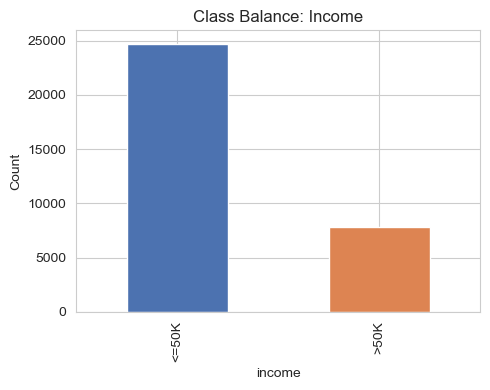

In [6]:
print(train['income'].value_counts(normalize=True) * 100)

plt.figure(figsize=(5, 4))
train['income'].value_counts().plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title('Class Balance: Income')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 2.5 Correlation heatmap
`fnlwgt` is a census sampling weight, not a real predictor — it shows ~0 correlation.

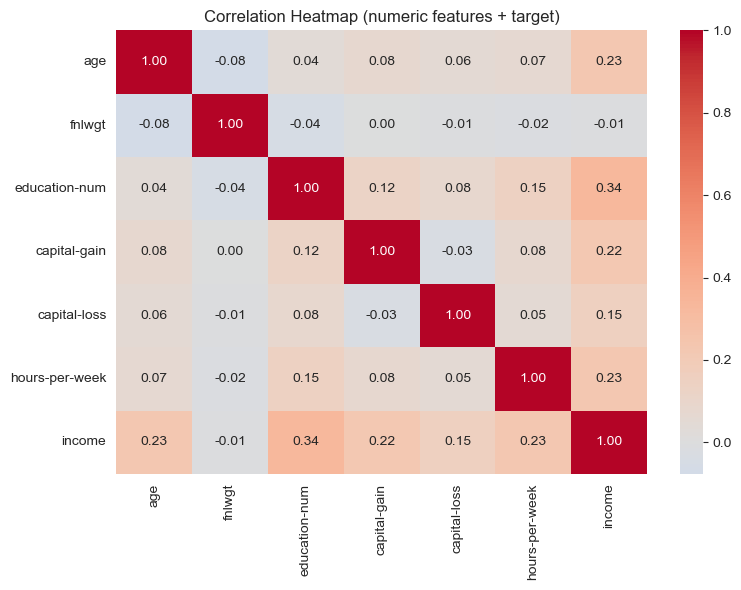

education-num     0.335154
age               0.234037
hours-per-week    0.229689
capital-gain      0.223329
capital-loss      0.150526
fnlwgt           -0.009463
Name: income, dtype: float64


In [8]:
numeric_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
df_corr = train[numeric_cols].copy()
df_corr['income'] = (train['income'] == '>50K').astype(int)

plt.figure(figsize=(8, 6))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (numeric features + target)')
plt.tight_layout()
plt.show()

print(df_corr.corr()['income'].drop('income').sort_values(ascending=False))

### 2.6 Income rate by categorical feature

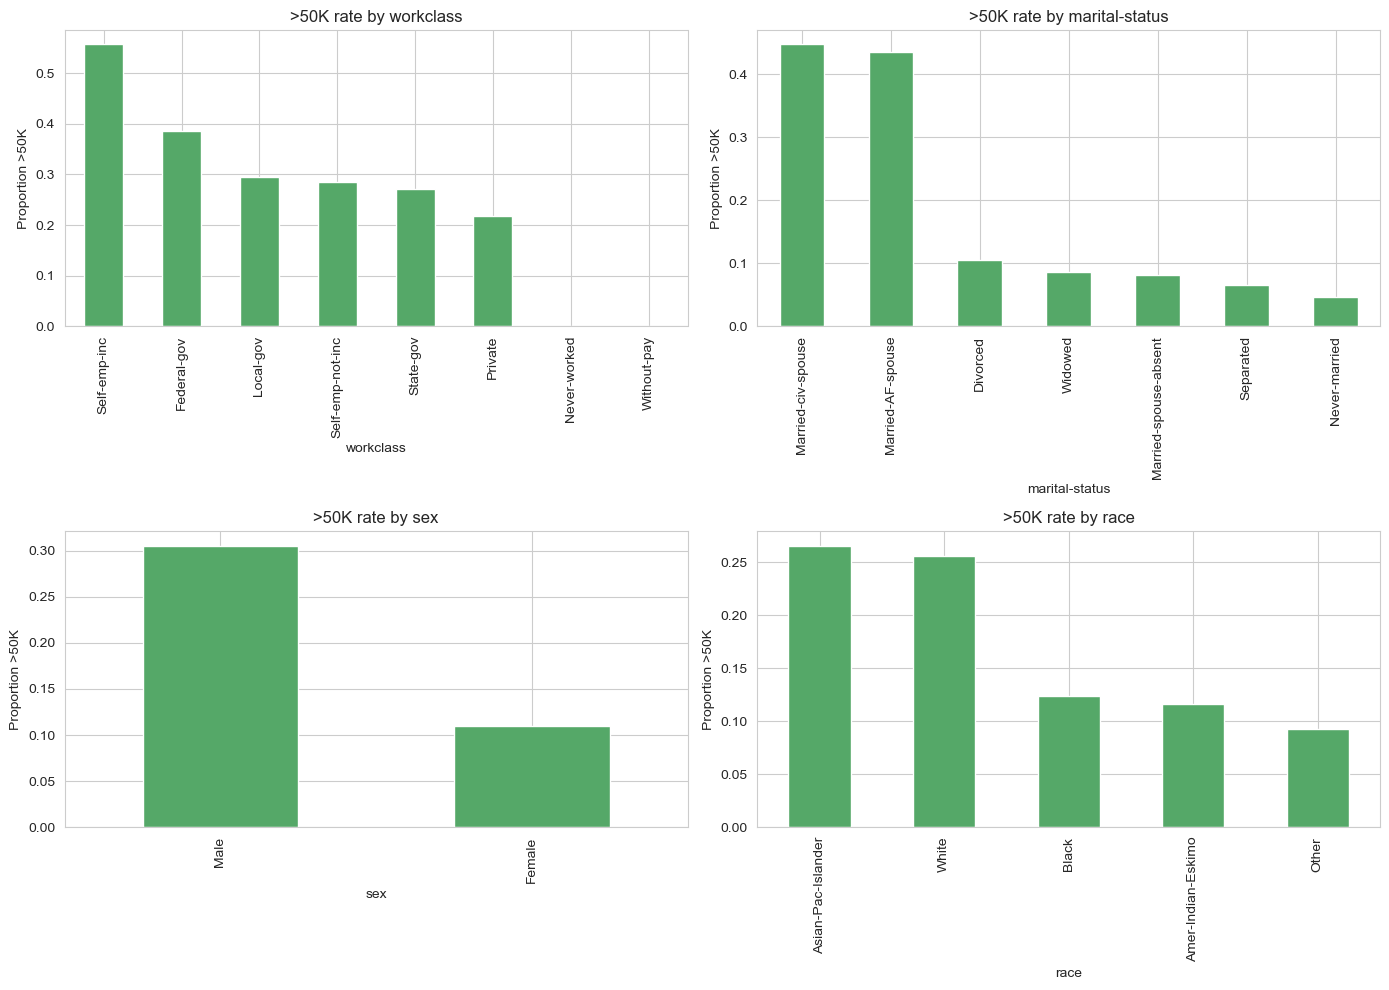

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for ax, col in zip(axes, ['workclass', 'marital-status', 'sex', 'race']):
    rate = train.groupby(col)['income'].apply(lambda x: (x == '>50K').mean()).sort_values(ascending=False)
    rate.plot(kind='bar', ax=ax, color='#55A868')
    ax.set_title(f'>50K rate by {col}')
    ax.set_ylabel('Proportion >50K')
plt.tight_layout()
plt.show()

## 3. Data Preparation for ML

- Drop `fnlwgt` (census sampling weight, not a real predictor — confirmed ~0 correlation above)
- Fill missing categorical values (`workclass`, `occupation`, `native-country`) with `'Unknown'` rather than dropping rows, to keep all ~32.5K training rows
- Group rare `native-country` categories (<1% frequency) into `'Other'` to avoid exploding into ~40 one-hot columns
- One-hot encode all categorical features
- Encode target as binary (1 = `>50K`, 0 = `<=50K`)
- Apply the exact same preprocessing to the official `adult.test` set so we can do a final generalization check on genuinely held-out data

In [10]:
def prepare(df_raw, country_categories=None, feature_columns=None):
    df = df_raw.drop(columns=['fnlwgt']).copy()

    cat_cols_fill = ['workclass', 'occupation', 'native-country']
    for c in cat_cols_fill:
        df[c] = df[c].fillna('Unknown')

    if country_categories is None:
        # Fit rare-category grouping on this (training) data
        freq = df['native-country'].value_counts(normalize=True)
        country_categories = freq[freq >= 0.01].index.tolist()
    df['native-country'] = df['native-country'].apply(
        lambda x: x if x in country_categories else 'Other'
    )

    df['income'] = (df['income'] == '>50K').astype(int)

    cat_cols_ohe = ['workclass', 'education', 'marital-status', 'occupation',
                    'relationship', 'race', 'sex', 'native-country']
    df = pd.get_dummies(df, columns=cat_cols_ohe, drop_first=True)

    if feature_columns is not None:
        # Align test-set columns to the training set (add any missing dummy cols as 0,
        # drop any extra ones not seen in training)
        df = df.reindex(columns=feature_columns + ['income'], fill_value=0)

    return df, country_categories

train_prepped, country_categories = prepare(train)
feature_columns = [c for c in train_prepped.columns if c != 'income']

test_prepped, _ = prepare(test, country_categories=country_categories, feature_columns=feature_columns)

X = train_prepped[feature_columns]
y = train_prepped['income']
X_test_final = test_prepped[feature_columns]
y_test_final = test_prepped['income']

print("Feature count:", X.shape[1])
print("Train rows:", X.shape[0], " Held-out test rows:", X_test_final.shape[0])

Feature count: 61
Train rows: 32561  Held-out test rows: 16281


### 3.1 Train/validation split + scaling
Stratified split of the training data (target is imbalanced, ~76/24).

In [11]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_final_scaled = scaler.transform(X_test_final)

print(f"Train size: {X_train.shape[0]}, Validation size: {X_val.shape[0]}, Held-out test size: {X_test_final.shape[0]}")
print(f"Train class balance:\n{y_train.value_counts(normalize=True)}")

Train size: 26048, Validation size: 6513, Held-out test size: 16281
Train class balance:
income
0    0.759175
1    0.240825
Name: proportion, dtype: float64


## 4. Model Training

In [12]:
SVM_SUBSAMPLE_SIZE = 8000  # RBF SVM scales poorly with rows; subsample for speed

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=10,
                                             random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                              eval_metric='logloss', random_state=RANDOM_STATE),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'Naive Bayes': GaussianNB(),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'KNN (k=15)': KNeighborsClassifier(n_neighbors=15, n_jobs=-1),
}

## 5. Evaluation
### 5.1 Train each model, evaluate on the validation split


Logistic Regression
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      4945
        >50K       0.74      0.62      0.67      1568

    accuracy                           0.86      6513
   macro avg       0.81      0.77      0.79      6513
weighted avg       0.85      0.86      0.85      6513


Decision Tree
              precision    recall  f1-score   support

       <=50K       0.87      0.95      0.91      4945
        >50K       0.79      0.56      0.65      1568

    accuracy                           0.86      6513
   macro avg       0.83      0.76      0.78      6513
weighted avg       0.85      0.86      0.85      6513


Random Forest
              precision    recall  f1-score   support

       <=50K       0.87      0.96      0.91      4945
        >50K       0.81      0.56      0.66      1568

    accuracy                           0.86      6513
   macro avg       0.84      0.76      0.79      6513
weighted avg       0.86

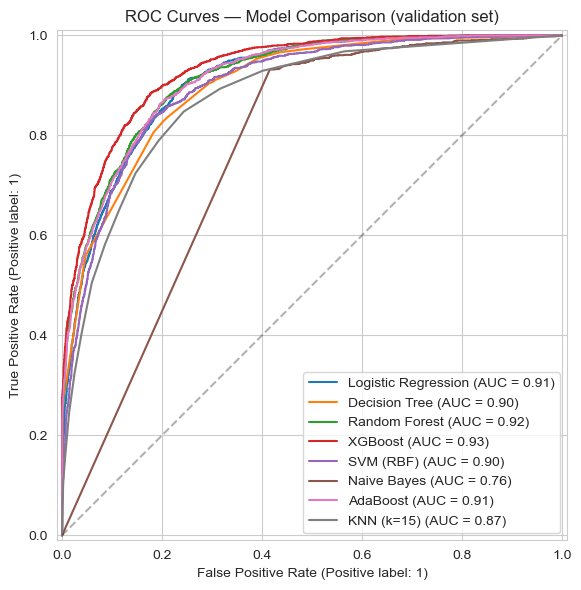

In [13]:
results = []
fig, ax = plt.subplots(figsize=(7, 6))

y_preds = {}  # cache predictions for the confusion-matrix cell below

for name, model in models.items():
    if name == 'SVM (RBF)' and X_train_scaled.shape[0] > SVM_SUBSAMPLE_SIZE:
        X_fit, _, y_fit, _ = train_test_split(
            X_train_scaled, y_train, train_size=SVM_SUBSAMPLE_SIZE,
            random_state=RANDOM_STATE, stratify=y_train
        )
    else:
        X_fit, y_fit = X_train_scaled, y_train
    model.fit(X_fit, y_fit)
    y_pred = model.predict(X_val_scaled)
    y_proba = model.predict_proba(X_val_scaled)[:, 1]
    y_preds[name] = y_pred

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_proba)

    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec,
                     'Recall': rec, 'F1': f1, 'ROC_AUC': auc})

    print(f"\n{'=' * 50}\n{name}\n{'=' * 50}")
    print(classification_report(y_val, y_pred, target_names=['<=50K', '>50K']))

    # Explicitly plot onto the ROC figure's own axes (not pyplot's "current
    # figure", which changes as soon as any other figure is created).
    RocCurveDisplay.from_predictions(y_val, y_proba, name=name, ax=ax)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_title('ROC Curves — Model Comparison (validation set)')
fig.tight_layout()
plt.show()

### 5.1b Confusion matrices

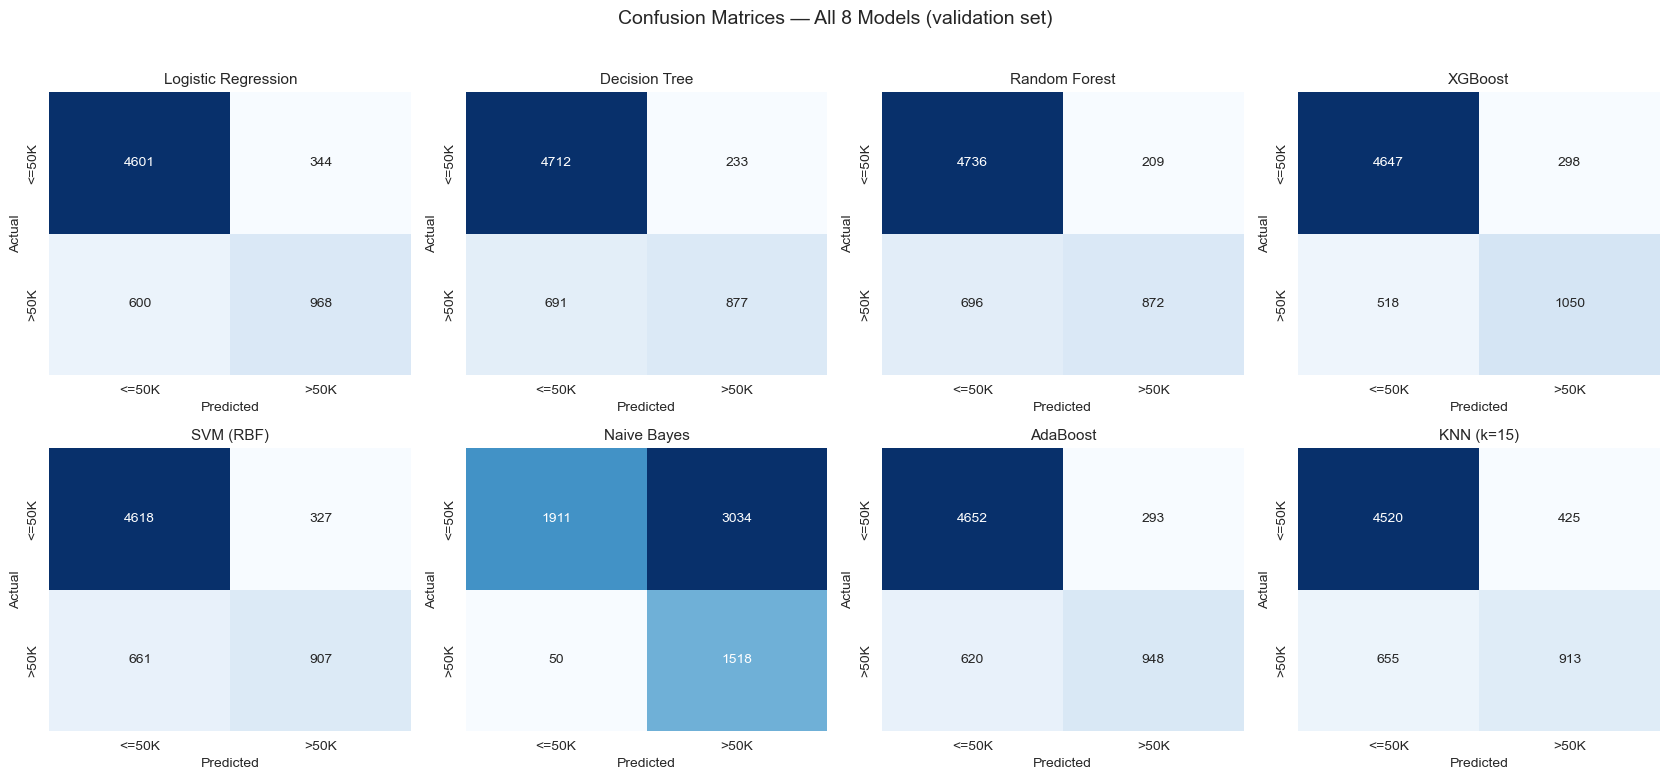

              Model  True Negatives  False Positives  False Negatives  True Positives  True Positive Rate  True Negative Rate  False Positive Rate  False Negative Rate
      Random Forest            4736              209              696             872            0.556122            0.957735             0.042265             0.443878
      Decision Tree            4712              233              691             877            0.559311            0.952882             0.047118             0.440689
           AdaBoost            4652              293              620             948            0.604592            0.940748             0.059252             0.395408
            XGBoost            4647              298              518            1050            0.669643            0.939737             0.060263             0.330357
          SVM (RBF)            4618              327              661             907            0.578444            0.933873             0.066127             0

In [14]:
model_order = list(models.keys())
n_models = len(model_order)
n_cols = 4
n_rows = -(-n_models // n_cols)  # ceil division

fig_cm, axes_cm = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.8 * n_rows))
axes_cm = axes_cm.flatten()

cm_summary = []

for i, name in enumerate(model_order):
    y_pred = y_preds[name]
    cm = confusion_matrix(y_val, y_pred)
    tn, fp, fn, tp = cm.ravel()
    cm_summary.append({
        'Model': name, 'True Negatives': tn, 'False Positives': fp,
        'False Negatives': fn, 'True Positives': tp,
        'True Positive Rate': tp / (tp + fn),   #  Recall / Sensitivity
        'True Negative Rate': tn / (tn + fp),   #  Specificity
        'False Positive Rate': fp / (fp + tn),
        'False Negative Rate': fn / (fn + tp),
    })

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'],
                ax=axes_cm[i], cbar=False)
    axes_cm[i].set_title(name, fontsize=11)
    axes_cm[i].set_ylabel('Actual')
    axes_cm[i].set_xlabel('Predicted')

# Hide any unused subplot slots (grid may have more cells than models)
for j in range(n_models, len(axes_cm)):
    axes_cm[j].axis('off')

fig_cm.suptitle('Confusion Matrices — All 8 Models (validation set)', fontsize=14, y=1.02)
fig_cm.tight_layout()
plt.show()

cm_summary_df = pd.DataFrame(cm_summary).sort_values('False Positive Rate')
cm_summary_df.to_csv('outputs/confusion_matrix_summary.csv', index=False)
print(cm_summary_df.to_string(index=False))

### 5.2 Compare models side by side

              Model  Accuracy  Precision   Recall       F1  ROC_AUC
            XGBoost  0.874712   0.778932 0.669643 0.720165 0.931426
           AdaBoost  0.859819   0.763900 0.604592 0.674973 0.914321
Logistic Regression  0.855059   0.737805 0.617347 0.672222 0.910102
      Random Forest  0.861047   0.806660 0.556122 0.658362 0.915849
      Decision Tree  0.858130   0.790090 0.559311 0.654966 0.898136
          SVM (RBF)  0.848303   0.735008 0.578444 0.647395 0.898136
         KNN (k=15)  0.834178   0.682362 0.582270 0.628355 0.874522
        Naive Bayes  0.526485   0.333480 0.968112 0.496078 0.763530


<Figure size 800x500 with 0 Axes>

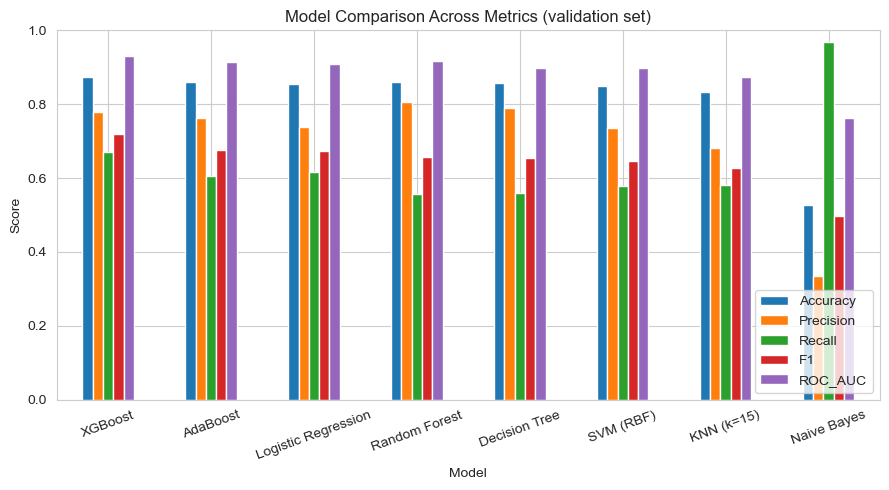

In [15]:
results_df = pd.DataFrame(results).sort_values('F1', ascending=False)
print(results_df.to_string(index=False))
results_df.to_csv('outputs/model_comparison.csv', index=False)

plt.figure(figsize=(8, 5))
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']].plot(
    kind='bar', figsize=(9, 5))
plt.title('Model Comparison Across Metrics (validation set)')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 5.3 Feature importance (Random Forest)

marital-status_Married-civ-spouse    0.183817
capital-gain                         0.174987
education-num                        0.121488
age                                  0.071936
marital-status_Never-married         0.063983
hours-per-week                       0.048697
capital-loss                         0.038582
relationship_Not-in-family           0.033253
occupation_Exec-managerial           0.032812
sex_Male                             0.031082
occupation_Prof-specialty            0.023276
education_Bachelors                  0.023199
relationship_Own-child               0.022700
relationship_Unmarried               0.015874
education_Masters                    0.014402
dtype: float64


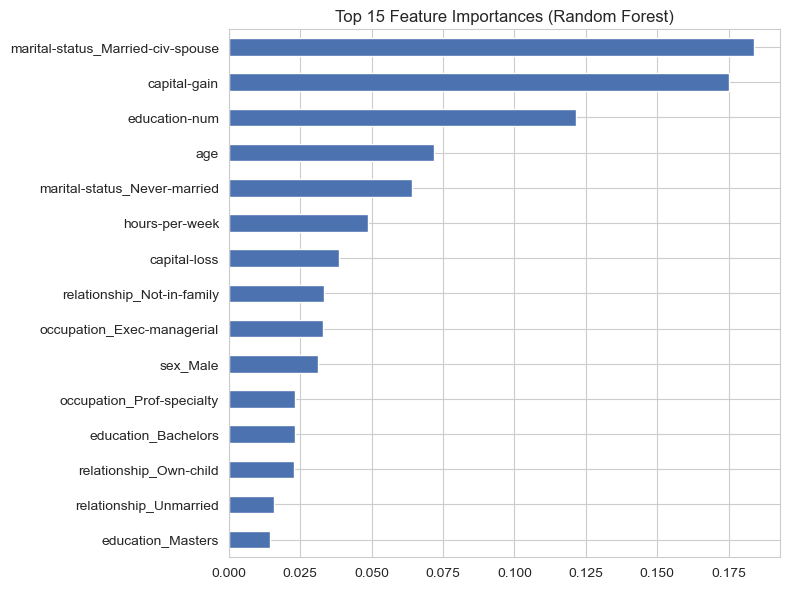

In [16]:
rf = models['Random Forest']
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances.head(15))

plt.figure(figsize=(8, 6))
importances.head(15).plot(kind='barh', color='#4C72B0')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 5.4 Final check on the genuinely held-out `adult.test` set

Everything above was evaluated on a validation split carved out of `adult.data`. As a first generalization check, we evaluate just the single best-performing model (by validation F1) on the official `adult.test` file, which it has never seen in any form. Section 5.5 immediately below extends this to all 8 models.

Best model by validation F1: XGBoost

Held-out test performance (XGBoost):
              precision    recall  f1-score   support

       <=50K       0.90      0.94      0.92     12435
        >50K       0.77      0.66      0.71      3846

    accuracy                           0.87     16281
   macro avg       0.83      0.80      0.81     16281
weighted avg       0.87      0.87      0.87     16281

ROC-AUC: 0.92730643443671


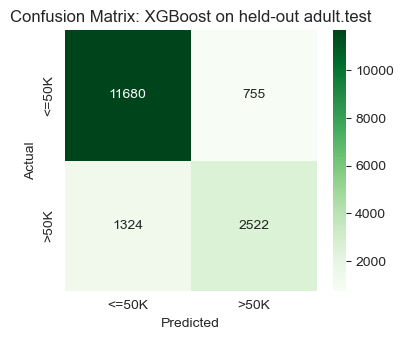

In [17]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"Best model by validation F1: {best_model_name}")

y_test_pred = best_model.predict(X_test_final_scaled)
y_test_proba = best_model.predict_proba(X_test_final_scaled)[:, 1]

print(f"\nHeld-out test performance ({best_model_name}):")
print(classification_report(y_test_final, y_test_pred, target_names=['<=50K', '>50K']))
print("ROC-AUC:", roc_auc_score(y_test_final, y_test_proba))

cm = confusion_matrix(y_test_final, y_test_pred)
plt.figure(figsize=(4, 3.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
plt.title(f'Confusion Matrix: {best_model_name} on held-out adult.test')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### 5.5 Evaluating ALL 8 models on the official held-out test set

The check above only evaluated the single best model (by validation F1) on `adult.test`. For full transparency, here every model — already fitted on the training set only — is also evaluated on the official test file, so the validation-based comparison table above (Section 5.2) can be directly compared against genuinely held-out performance.

In [18]:
results_test = []
for name, model in models.items():
    y_test_pred_i = model.predict(X_test_final_scaled)
    y_test_proba_i = model.predict_proba(X_test_final_scaled)[:, 1]
    results_test.append({
        'Model': name,
        'Accuracy_test': accuracy_score(y_test_final, y_test_pred_i),
        'Precision_test': precision_score(y_test_final, y_test_pred_i),
        'Recall_test': recall_score(y_test_final, y_test_pred_i),
        'F1_test': f1_score(y_test_final, y_test_pred_i),
        'ROC_AUC_test': roc_auc_score(y_test_final, y_test_proba_i),
    })
results_test_df = pd.DataFrame(results_test)

val_vs_test = results_df[['Model', 'Accuracy', 'F1', 'ROC_AUC']].rename(
    columns={'Accuracy': 'Accuracy_val', 'F1': 'F1_val', 'ROC_AUC': 'ROC_AUC_val'}
).merge(results_test_df[['Model', 'Accuracy_test', 'F1_test', 'ROC_AUC_test']], on='Model')
val_vs_test = val_vs_test.sort_values('Accuracy_test', ascending=False)
print(val_vs_test.to_string(index=False))
val_vs_test.to_csv('outputs/val_vs_test_all_models.csv', index=False)

              Model  Accuracy_val   F1_val  ROC_AUC_val  Accuracy_test  F1_test  ROC_AUC_test
            XGBoost      0.874712 0.720165     0.931426       0.872305 0.708129      0.927306
      Random Forest      0.861047 0.658362     0.915849       0.858854 0.646026      0.911715
           AdaBoost      0.859819 0.674973     0.914321       0.857564 0.659821      0.911275
      Decision Tree      0.858130 0.654966     0.898136       0.855291 0.638095      0.895119
Logistic Regression      0.855059 0.672222     0.910102       0.852589 0.656160      0.903833
          SVM (RBF)      0.848303 0.647395     0.898136       0.846815 0.633127      0.887357
         KNN (k=15)      0.834178 0.628355     0.874522       0.834715 0.618135      0.869427
        Naive Bayes      0.526485 0.496078     0.763530       0.522388 0.485714      0.751018


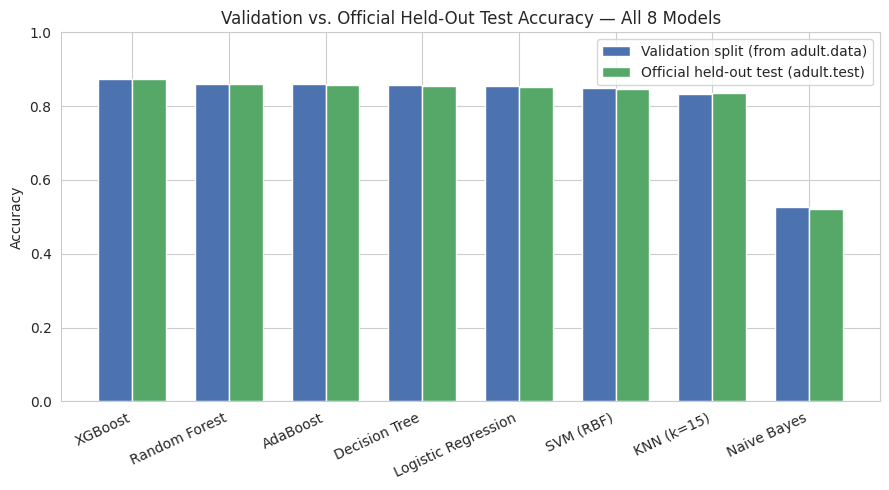


Mean absolute difference between validation and test accuracy: 0.0023


In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(val_vs_test))
width = 0.35
ax.bar(x_pos - width/2, val_vs_test['Accuracy_val'], width, label='Validation split (from adult.data)', color='#4C72B0')
ax.bar(x_pos + width/2, val_vs_test['Accuracy_test'], width, label='Official held-out test (adult.test)', color='#55A868')
ax.set_xticks(x_pos)
ax.set_xticklabels(val_vs_test['Model'], rotation=25, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Validation vs. Official Held-Out Test Accuracy — All 8 Models')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nMean absolute difference between validation and test accuracy: "
      f"{(val_vs_test['Accuracy_val'] - val_vs_test['Accuracy_test']).abs().mean():.4f}")

**Reading this:** small, consistent differences between validation and test accuracy (typically well under 1 point) indicate the validation split was a reliable stand-in for the official test set throughout this notebook — the model comparisons and fairness experiments elsewhere, which use the validation split for efficiency, are trustworthy estimates of true held-out performance, not just artifacts of a lucky split.